# Notebook 16 v2 — MELU-Δt vs DAGMM / GOAD / NeuTraL-AD / ICL
## With per-dataset hyperparameter selection

### Why hyperparameter tuning is necessary

Previous version used fixed hyperparameters → GOAD inverted on low-dim data,
DAGMM failed on small datasets, ICL near-random throughout.

The original papers each tune at least one key hyperparameter per dataset.
A fair comparison requires the same treatment for all methods.

### Tuning protocol (valid — uses training data only)

```
For each dataset and method:
  1. Hold out 20% of training inliers as proxy validation set
  2. Train on remaining 80% with each candidate config (fast: 30 epochs)
  3. Select config by proxy metric on proxy validation set (NO test data used)
  4. Retrain best config on FULL training set (100 epochs)
  5. Evaluate on test set (held-out 50% inliers + all outliers)
```

Proxy metrics (label-free, training-data-only):
- **DAGMM**: min mean energy on proxy val inliers (lower = model treats them as normal)
- **GOAD**: max transform classification accuracy on proxy val inliers
- **NeuTraL-AD**: max mean cosine similarity on proxy val inliers
- **ICL**: min mean latent distance to centroid on proxy val inliers

### Hyperparameter grids (from published papers)

| Method | Grid | Ref |
|---|---|---|
| DAGMM | n_comp ∈ {1, 2, 4} | Zong et al. ICLR 2018, App. A |
| GOAD | n_trans ∈ {16, 32, 64}, orthogonal transforms | Bergman & Hoshen ICLR 2020, App. B |
| NeuTraL-AD | n_trans ∈ {4,8,11}, tau ∈ {0.05,0.07} | Qiu et al. ICML 2021, App. C |
| ICL | noise ∈ {0.05,0.10,0.20}, n_aug ∈ {2,4} | Shenkar & Wolf ICLR 2022 |

### Runtime
- Quick (N_SEEDS=2, grid_epochs=30): ~2–4 hours
- Full  (N_SEEDS=10, grid_epochs=30): ~15–25 hours


## Cell 1 — Imports and config

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc, gammaln
from scipy.stats import wilcoxon, friedmanchisquare, rankdata
from sklearn.datasets import load_digits, load_breast_cancer, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings, time, itertools
warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

# ── Experiment config ─────────────────────────────────────────────────────────
N_SEEDS       = 5      # set to 2 for quick preview
TRAIN_FRAC    = 0.50    # 50/50 inlier split per seed
PROXY_FRAC    = 0.80    # 80% of training inliers for grid training, 20% for proxy val
GRID_EPOCHS   = 30      # epochs for each candidate config during grid search
FULL_EPOCHS   = 100     # epochs for final model after config selection
LR            = 1e-3
MELU_EPOCHS_PRE  = 60
MELU_EPOCHS_FINE = 80

METHODS = ["MELU-Δt","DAGMM","GOAD","NeuTraL-AD","ICL"]
COLORS  = {"MELU-Δt":"#1D9E75","DAGMM":"#534AB7",
           "GOAD":"#BA7517","NeuTraL-AD":"#D85A30","ICL":"#888780"}

# ── Hyperparameter grids ──────────────────────────────────────────────────────
GRIDS = {
    "DAGMM":      [{"n_comp": c}           for c in [1, 2, 4]],
    "GOAD":       [{"n_trans": n}          for n in [16, 32, 64]],
    "NeuTraL-AD": [{"n_trans": n, "tau": t}
                   for n, t in itertools.product([4, 8, 11], [0.05, 0.07])],
    "ICL":        [{"noise": s, "n_aug": a}
                   for s, a in itertools.product([0.05, 0.10, 0.20], [2, 4])],
}

def lat_for(dim): return max(4, min(dim//2, 16))
def hid_for(dim): return max(64, dim*4)

print(f"PyTorch {torch.__version__} ✓")
print()
print("Hyperparameter grids:")
for m, grid in GRIDS.items():
    print(f"  {m:<14}: {len(grid)} configs: {grid}")
print()
print(f"Per-dataset tuning: hold out {1-PROXY_FRAC:.0%} of training inliers as proxy val")
print(f"Train each config {GRID_EPOCHS} epochs → pick best → retrain {FULL_EPOCHS} epochs")


PyTorch 2.5.1+cu121 ✓

Hyperparameter grids:
  DAGMM         : 3 configs: [{'n_comp': 1}, {'n_comp': 2}, {'n_comp': 4}]
  GOAD          : 3 configs: [{'n_trans': 16}, {'n_trans': 32}, {'n_trans': 64}]
  NeuTraL-AD    : 6 configs: [{'n_trans': 4, 'tau': 0.05}, {'n_trans': 4, 'tau': 0.07}, {'n_trans': 8, 'tau': 0.05}, {'n_trans': 8, 'tau': 0.07}, {'n_trans': 11, 'tau': 0.05}, {'n_trans': 11, 'tau': 0.07}]
  ICL           : 6 configs: [{'noise': 0.05, 'n_aug': 2}, {'noise': 0.05, 'n_aug': 4}, {'noise': 0.1, 'n_aug': 2}, {'noise': 0.1, 'n_aug': 4}, {'noise': 0.2, 'n_aug': 2}, {'noise': 0.2, 'n_aug': 4}]

Per-dataset tuning: hold out 20% of training inliers as proxy val
Train each config 30 epochs → pick best → retrain 100 epochs


## Cell 2 — Shared utilities (fixed BaseAE with encode_elu)

In [15]:
class StudentTCDF(torch.autograd.Function):
    NU=5.0
    @staticmethod
    def forward(ctx,x):
        nu=StudentTCDF.NU; xn=x.detach().cpu().numpy()
        z=nu/(nu+np.clip(xn**2,1e-30,None))
        ib=betainc(nu/2,0.5,np.clip(z,1e-12,1-1e-12))
        ctx.save_for_backward(x)
        return torch.tensor(np.where(xn>=0,1.-ib/2.,ib/2.),dtype=x.dtype,device=x.device)
    @staticmethod
    def backward(ctx,g):
        x,=ctx.saved_tensors; nu=StudentTCDF.NU; xn=x.detach().cpu().numpy()
        lc=gammaln((nu+1)/2)-gammaln(nu/2)-.5*np.log(nu*np.pi)
        pdf=np.exp(lc-(nu+1)/2*np.log(1+xn**2/nu))
        return g*torch.tensor(pdf,dtype=x.dtype,device=x.device)
tcdf=StudentTCDF.apply

class BaseAE(nn.Module):
    def __init__(self,dim,hid,lat):
        super().__init__()
        self.W1=nn.Linear(dim,hid); self.W2=nn.Linear(hid,lat); self.dec=nn.Linear(lat,dim)
        for m in [self.W1,self.W2,self.dec]:
            nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)
    def encode_elu(self,x): return self.W2(F.elu(F.silu(self.W1(x))))
    def encode(self,x):     return self.W2(F.silu(self.W1(x)))
    def forward(self,x):    return self.dec(self.encode_elu(x))
    def recon_err(self,x):
        with torch.no_grad(): return (x-self(x)).abs().mean(1)

def fast_mcd(Z,hf=0.75,ns=6,nc=5):
    n,d=Z.shape; h=max(int(n*hf),d+1); bd=np.inf; bm=bc=None
    for _ in range(ns):
        idx=np.random.choice(n,h,replace=False); sub=Z[idx]
        for _ in range(nc):
            mu=sub.mean(0); dv=sub-mu
            cov=dv.T@dv/max(len(sub)-1,1)+1e-4*np.eye(d)
            Si=np.linalg.inv(cov)
            ds=np.sqrt(np.maximum(np.einsum('bi,ij,bj->b',Z-mu,Si,Z-mu),0))
            idx=np.argsort(ds)[:h]; sub=Z[idx]
        mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)
        det=np.linalg.det(cov+1e-4*np.eye(d))
        if det<bd: bd=det; bm=mu; bc=cov
    try:
        L=np.linalg.cholesky(bc+1e-4*np.eye(d)); Li=np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li)>1e7: Li=np.eye(d)
    except: Li=np.eye(d)
    return bm,bc,Li

def make_optim(params, lr, n_ep):
    """Adam with cosine LR annealing — matches NeuTraL-AD paper."""
    opt=optim.Adam(params,lr=lr)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=n_ep,eta_min=lr*0.01)
    return opt, sched

def bce_pl(er, Xi_t, model, pct=85, lam=0.5, enc_frozen=None):
    """BCE pseudo-label loss for MELU."""
    model.eval()
    with torch.no_grad():
        er_all=(model.recon_err(Xi_t,enc_frozen) if enc_frozen
                else model.recon_err(Xi_t)).numpy()
    py=torch.tensor((er_all>np.percentile(er_all,pct)).astype(np.float32))
    model.train()
    em,eM=er.detach().min(),er.detach().max()
    pb=((er-em)/(eM-em+1e-8)).clamp(1e-6,1-1e-6)
    return lam*F.binary_cross_entropy(pb,py[:len(er)])

print("BaseAE, fast_mcd, utilities defined ✓")


BaseAE, fast_mcd, utilities defined ✓


## Cell 3 — MELU-Δt (unchanged from NB15)

In [16]:
class MELUGate(nn.Module):
    def __init__(self,lat):
        super().__init__()
        self.register_buffer('mu',torch.zeros(lat))
        self.register_buffer('Li',torch.eye(lat))
        self.register_buffer('tau',torch.tensor(1.5))
    def set_mcd(self,mu_np,Li_np,tv):
        dev=self.mu.device
        self.mu=torch.tensor(mu_np,dtype=torch.float32,device=dev)
        self.Li=torch.tensor(Li_np,dtype=torch.float32,device=dev)
        self.tau=torch.tensor(float(tv),device=dev)
    def forward(self,Z):
        w=(Z-self.mu.unsqueeze(0))@self.Li.T; return w.norm(dim=1)

class MELU_AE(nn.Module):
    def __init__(self,dim,hid,lat):
        super().__init__()
        self.W1=nn.Linear(dim,hid); self.W2=nn.Linear(hid,lat); self.W3=nn.Linear(lat,dim)
        self.la=nn.Parameter(torch.log(torch.tensor(1.0)))
        self.lb=nn.Parameter(torch.log(torch.tensor(0.5)))
        self.gate=MELUGate(lat); self.gate_on=False
        for m in [self.W1,self.W2,self.W3]: nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)
    @property
    def alpha(self): return self.la.exp()
    @property
    def beta(self):  return self.lb.exp()
    def encode(self,x,ef=None):
        h1=F.silu(self.W1(x)); T1=h1*tcdf(h1)
        if self.gate_on and ef is not None:
            with torch.no_grad(): Zf=ef.encode_elu(x)
            m=self.gate(Zf); g=(m>=self.gate.tau).float().unsqueeze(1)
            amp=self.alpha*h1.sign()*torch.tanh(self.beta*(m.unsqueeze(1)-self.gate.tau).clamp(-8,8))
            return self.W2(T1+g*amp)
        return self.W2(T1)
    def forward(self,x,ef=None): return self.W3(self.encode(x,ef))
    def recon_err(self,x,ef=None):
        with torch.no_grad(): return (x-self(x,ef)).abs().mean(1)

def run_melu(Xi_tr_np,Xi_all_np,X_test_np,y_test_np,seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    dim=X_test_np.shape[1]; lat=lat_for(dim); hid=hid_for(dim)
    Xi_tr=torch.tensor(Xi_tr_np,dtype=torch.float32)
    X_te =torch.tensor(X_test_np,dtype=torch.float32)
    # Stage 1
    ae=BaseAE(dim,hid,lat); opt1=optim.Adam(ae.parameters(),lr=LR); wu1=int(MELU_EPOCHS_PRE*.2)
    for ep in range(MELU_EPOCHS_PRE):
        ae.train(); perm=torch.randperm(len(Xi_tr))
        for i in range(0,len(Xi_tr),64):
            xb=Xi_tr[perm[i:i+64]]; er=(xb-ae(xb)).abs().mean(1)
            loss=er.mean()+(bce_pl(er,Xi_tr,ae) if ep>=wu1 else 0)
            opt1.zero_grad(); loss.backward(); opt1.step()
    # Stage 2
    ae.eval(); Xi_all_t=torch.tensor(Xi_all_np,dtype=torch.float32)
    with torch.no_grad(): Z_all=ae.encode_elu(Xi_all_t).numpy()
    mu_l,_,Li_l=fast_mcd(Z_all); w=(Z_all-mu_l)@Li_l.T
    dm=np.sqrt(np.maximum((w**2).sum(1),0)); tau=dm.mean(); gp=float((dm>tau).mean())
    # Stage 3
    melu=MELU_AE(dim,hid,lat)
    melu.W1.weight.data=ae.W1.weight.data.clone(); melu.W1.bias.data=ae.W1.bias.data.clone()
    melu.W2.weight.data=ae.W2.weight.data.clone(); melu.W2.bias.data=ae.W2.bias.data.clone()
    melu.W3.weight.data=ae.dec.weight.data.clone(); melu.W3.bias.data=ae.dec.bias.data.clone()
    melu.gate.set_mcd(mu_l,Li_l,tau)
    for p in ae.parameters(): p.requires_grad_(False)
    opt3=optim.Adam(melu.parameters(),lr=LR*.5); wu3=int(MELU_EPOCHS_FINE*.2)
    for ep in range(MELU_EPOCHS_FINE):
        melu.gate_on=(ep>=wu3); melu.train(); perm=torch.randperm(len(Xi_tr))
        for i in range(0,len(Xi_tr),64):
            xb=Xi_tr[perm[i:i+64]]; er=(xb-melu(xb,ae)).abs().mean(1)
            loss=er.mean()+(bce_pl(er,Xi_tr,melu,enc_frozen=ae) if ep>=wu3 else 0)
            opt3.zero_grad(); loss.backward(); opt3.step()
    melu.eval(); melu.gate_on=True
    er=melu.recon_err(X_te,ae).numpy()
    return float(roc_auc_score(y_test_np,er)), gp

print("MELU-Δt defined ✓")


MELU-Δt defined ✓


## Cell 4 — Hyperparameter tuning framework

In [17]:
def split_proxy(Xi_tr, proxy_frac=PROXY_FRAC, seed=0):
    """Split training inliers into fit/proxy-val for HP selection."""
    rng=np.random.RandomState(seed)
    idx=rng.permutation(len(Xi_tr))
    n_fit=max(8,int(len(Xi_tr)*proxy_frac))
    return Xi_tr[idx[:n_fit]], Xi_tr[idx[n_fit:]]


def select_hp(method_fn, grid, Xi_fit_np, Xi_val_np, proxy_fn, seed=0):
    """
    Train each config in grid on Xi_fit for GRID_EPOCHS.
    Evaluate proxy_fn(model, Xi_val) → score (higher=better).
    Return best config dict.
    
    proxy_fn signature: proxy_fn(model, Xi_val_t) -> float
    """
    best_cfg=grid[0]; best_score=-np.inf
    Xi_fit_t=torch.tensor(Xi_fit_np,dtype=torch.float32)
    Xi_val_t=torch.tensor(Xi_val_np,dtype=torch.float32)
    for cfg in grid:
        try:
            score=method_fn(cfg,Xi_fit_t,Xi_val_t,seed)
            if score>best_score: best_score=score; best_cfg=cfg
        except Exception: pass
    return best_cfg, best_score


# ── Proxy metrics (label-free, higher=better) ─────────────────────────────────
def proxy_dagmm(model,Xi_val_t):
    """Lower energy on val inliers = better. Return negative mean energy."""
    model.eval()
    with torch.no_grad():
        sc=model.score(Xi_val_t).numpy()
    return -float(np.mean(sc)) if not np.isnan(sc).any() else -np.inf

def proxy_goad(model,Xi_val_t):
    """Higher transform classification accuracy on val inliers = better."""
    model.eval(); N=len(Xi_val_t); K=model.n_trans; correct=0
    with torch.no_grad():
        for k in range(K):
            x_t=model.apply_transform(Xi_val_t,k)
            preds=model.head(model.feat(x_t)).argmax(1)
            correct+=(preds==k).sum().item()
    return correct/(N*K)

def proxy_neutral(model,Xi_val_t):
    """Higher mean cosine sim between x and T_k(x) on val inliers = better."""
    model.eval(); sims=[]
    with torch.no_grad():
        z_x=model.encode(Xi_val_t)
        for T in model.transforms:
            sims.append(F.cosine_similarity(z_x,model.encode(T(Xi_val_t)),dim=1).mean().item())
    return float(np.mean(sims)) if sims else -np.inf

def proxy_icl(model,Xi_val_t):
    """Lower mean latent distance to inlier centroid on val = better."""
    model.eval()
    with torch.no_grad():
        sc=model.score(Xi_val_t).numpy()
    return -float(np.mean(sc)) if not np.isnan(sc).any() else -np.inf

print("Hyperparameter selection framework defined ✓")
print()
print("Proxy metrics (all label-free, use training data only):")
print("  DAGMM:      -mean(energy on proxy val inliers)")
print("  GOAD:       transform classification accuracy on proxy val inliers")
print("  NeuTraL-AD: mean cosine similarity x → T_k(x) on proxy val inliers")
print("  ICL:        -mean latent distance to centroid on proxy val inliers")


Hyperparameter selection framework defined ✓

Proxy metrics (all label-free, use training data only):
  DAGMM:      -mean(energy on proxy val inliers)
  GOAD:       transform classification accuracy on proxy val inliers
  NeuTraL-AD: mean cosine similarity x → T_k(x) on proxy val inliers
  ICL:        -mean latent distance to centroid on proxy val inliers


## Cell 5 — DAGMM with n_comp tuning

In [18]:
class DAGMM(nn.Module):
    def __init__(self,dim,hid,lat,n_comp=2):
        super().__init__()
        self.ae=BaseAE(dim,hid,lat); self.n_comp=n_comp
        feat_dim=lat+2
        self.estim=nn.Sequential(
            nn.Linear(feat_dim,16),nn.Tanh(),nn.Dropout(0.5),
            nn.Linear(16,n_comp),nn.Softmax(dim=1))
        for m in self.estim.modules():
            if isinstance(m,nn.Linear): nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def features(self,x):
        z=self.ae.encode_elu(x); xh=self.ae.dec(z)
        ed=(x-xh).norm(dim=1,keepdim=True)/(x.norm(dim=1,keepdim=True)+1e-8)
        cs=F.cosine_similarity(x,xh,dim=1,eps=1e-8).unsqueeze(1)
        return z, torch.cat([z,ed,cs],dim=1), xh

    def _gmm_params(self,feat,gamma):
        K,d=self.n_comp,feat.shape[1]
        phi=gamma.mean(0)
        mu=(gamma.unsqueeze(2)*feat.unsqueeze(1)).sum(0)/(gamma.sum(0).unsqueeze(1)+1e-8)
        diff=feat.unsqueeze(1)-mu.unsqueeze(0)
        cov=(gamma.unsqueeze(2).unsqueeze(3)*diff.unsqueeze(3)*diff.unsqueeze(2)).sum(0)
        cov=cov/(gamma.sum(0).view(-1,1,1)+1e-8)+1e-2*torch.eye(d,device=feat.device).unsqueeze(0)
        return phi,mu,cov

    def _energy(self,feat,phi,mu,cov):
        d=feat.shape[1]; diff=feat.unsqueeze(1)-mu.unsqueeze(0)
        try:
            L=torch.linalg.cholesky(cov)
            ld=2*L.diagonal(dim1=-2,dim2=-1).log().sum(-1)
            Ld=torch.linalg.solve_triangular(L,diff.permute(0,1,3,2).reshape(-1,d,1),upper=False)
            mah2=Ld.squeeze(-1).pow(2).sum(-1).reshape(feat.shape[0],self.n_comp)
        except Exception:
            ld=cov.diagonal(dim1=-2,dim2=-1).clamp(1e-4).log().sum(-1)
            mah2=(diff.pow(2)/(cov.diagonal(dim1=-2,dim2=-1).unsqueeze(0)+1e-8)).sum(-1)
        return -(phi.log().unsqueeze(0)-0.5*(mah2+ld.unsqueeze(0))).logsumexp(-1)

    def dagmm_loss(self,x,lam1=0.1,lam2=0.005):
        z,feat,xh=self.features(x)
        recon=(x-xh).pow(2).mean()
        gamma=self.estim(feat)
        phi,mu,cov=self._gmm_params(feat,gamma)
        energy=self._energy(feat,phi,mu,cov)
        pen=phi.reciprocal().sum()
        return recon+lam1*energy.mean()+lam2*pen

    def score(self,x):
        with torch.no_grad():
            _,feat,_=self.features(x); gamma=self.estim(feat)
            phi,mu,cov=self._gmm_params(feat,gamma)
            return self._energy(feat,phi,mu,cov)


def _train_dagmm(cfg, Xi_t, Xi_val_t, seed, n_ep=None):
    """Train DAGMM with config, return proxy score."""
    n_ep=n_ep or GRID_EPOCHS
    torch.manual_seed(seed); np.random.seed(seed)
    dim=Xi_t.shape[1]; lat=lat_for(dim); hid=hid_for(dim)
    model=DAGMM(dim,hid,lat,n_comp=cfg["n_comp"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(n_ep):
        model.train(); perm=torch.randperm(len(Xi_t))
        for i in range(0,len(Xi_t),64):
            xb=Xi_t[perm[i:i+64]]
            if len(xb)<max(cfg["n_comp"]*2,4): continue
            try:
                loss=model.dagmm_loss(xb)
                if not(torch.isnan(loss) or torch.isinf(loss)):
                    opt.zero_grad(); loss.backward(); opt.step()
            except Exception: pass
    return proxy_dagmm(model,Xi_val_t)


def run_dagmm(Xi_tr_np,X_test_np,y_test_np,seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    dim=X_test_np.shape[1]; lat=lat_for(dim); hid=hid_for(dim)
    # HP selection
    Xi_fit,Xi_val=split_proxy(Xi_tr_np,seed=seed)
    Xi_fit_t=torch.tensor(Xi_fit,dtype=torch.float32)
    Xi_val_t=torch.tensor(Xi_val,dtype=torch.float32)
    best_cfg=GRIDS["DAGMM"][0]; best_s=-np.inf
    for cfg in GRIDS["DAGMM"]:
        try:
            s=_train_dagmm(cfg,Xi_fit_t,Xi_val_t,seed)
            if s>best_s: best_s=s; best_cfg=cfg
        except Exception: pass
    # Full training with best config
    Xi_tr_t=torch.tensor(Xi_tr_np,dtype=torch.float32)
    X_te_t=torch.tensor(X_test_np,dtype=torch.float32)
    model=DAGMM(dim,hid,lat,n_comp=best_cfg["n_comp"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(FULL_EPOCHS):
        model.train(); perm=torch.randperm(len(Xi_tr_t))
        for i in range(0,len(Xi_tr_t),64):
            xb=Xi_tr_t[perm[i:i+64]]
            if len(xb)<max(best_cfg["n_comp"]*2,4): continue
            try:
                loss=model.dagmm_loss(xb)
                if not(torch.isnan(loss) or torch.isinf(loss)):
                    opt.zero_grad(); loss.backward(); opt.step()
            except Exception: pass
    model.eval()
    try:
        sc=model.score(X_te_t).numpy()
        return float(roc_auc_score(y_test_np,sc)) if not np.isnan(sc).any() else 0.5, best_cfg
    except Exception: return 0.5, best_cfg

print("DAGMM with n_comp tuning defined ✓  (grid: n_comp ∈ {1,2,4})")


DAGMM with n_comp tuning defined ✓  (grid: n_comp ∈ {1,2,4})


## Cell 6 — GOAD with orthogonal transforms + n_trans tuning

In [19]:
class GOAD(nn.Module):
    """
    GOAD with ORTHOGONAL random transforms (paper uses Haar random orthogonal matrices).
    Score = mean per-sample CE loss across all K transforms.
    n_trans tuned via proxy classification accuracy.
    """
    def __init__(self,dim,hid,n_trans=32):
        super().__init__()
        self.n_trans=n_trans; self.dim=dim
        # Haar-distributed random orthogonal matrices
        torch.manual_seed(42)
        T=[]
        for _ in range(n_trans):
            Q,_=torch.linalg.qr(torch.randn(dim,dim))
            T.append(Q)
        self.register_buffer('T',torch.stack(T,0))   # [K,dim,dim]
        self.feat=nn.Sequential(nn.Linear(dim,hid),nn.LeakyReLU(0.1),nn.Linear(hid,64))
        self.head=nn.Linear(64,n_trans)
        for m in [self.feat[0],self.feat[2],self.head]:
            nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)

    def apply_transform(self,x,k):
        return (self.T[k].unsqueeze(0).expand(len(x),-1,-1)@x.unsqueeze(2)).squeeze(2)

    def goad_loss(self,x):
        N=x.shape[0]; K=self.n_trans
        t_idx=torch.randint(K,(N,),device=x.device)
        x_t=(self.T[t_idx]@x.unsqueeze(2)).squeeze(2)
        return F.cross_entropy(self.head(self.feat(x_t)),t_idx)

    def score(self,x):
        """Mean CE loss per sample (higher = harder to classify = more anomalous)."""
        N=x.shape[0]; K=self.n_trans; scores=torch.zeros(N,device=x.device)
        with torch.no_grad():
            for k in range(K):
                x_t=self.apply_transform(x,k)
                ce=F.cross_entropy(self.head(self.feat(x_t)),
                                   torch.full((N,),k,dtype=torch.long,device=x.device),
                                   reduction='none')
                scores=scores+ce
        return scores/K


def _train_goad(cfg,Xi_t,Xi_val_t,seed,n_ep=None):
    n_ep=n_ep or GRID_EPOCHS
    torch.manual_seed(seed); np.random.seed(seed)
    dim=Xi_t.shape[1]; hid=min(128,dim*4)
    model=GOAD(dim,hid,n_trans=cfg["n_trans"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(n_ep):
        model.train(); perm=torch.randperm(len(Xi_t))
        for i in range(0,len(Xi_t),64):
            xb=Xi_t[perm[i:i+64]]
            loss=model.goad_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
    return proxy_goad(model,Xi_val_t)


def run_goad(Xi_tr_np,X_test_np,y_test_np,seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    dim=X_test_np.shape[1]; hid=min(128,dim*4)
    Xi_fit,Xi_val=split_proxy(Xi_tr_np,seed=seed)
    Xi_fit_t=torch.tensor(Xi_fit,dtype=torch.float32)
    Xi_val_t=torch.tensor(Xi_val,dtype=torch.float32)
    best_cfg=GRIDS["GOAD"][0]; best_s=-np.inf
    for cfg in GRIDS["GOAD"]:
        try:
            s=_train_goad(cfg,Xi_fit_t,Xi_val_t,seed)
            if s>best_s: best_s=s; best_cfg=cfg
        except Exception: pass
    # Full training
    Xi_tr_t=torch.tensor(Xi_tr_np,dtype=torch.float32)
    X_te_t =torch.tensor(X_test_np,dtype=torch.float32)
    model=GOAD(dim,hid,n_trans=best_cfg["n_trans"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(FULL_EPOCHS):
        model.train(); perm=torch.randperm(len(Xi_tr_t))
        for i in range(0,len(Xi_tr_t),64):
            xb=Xi_tr_t[perm[i:i+64]]
            loss=model.goad_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    try:
        sc=model.score(X_te_t).numpy()
        return float(roc_auc_score(y_test_np,sc)) if not np.isnan(sc).any() else 0.5, best_cfg
    except Exception: return 0.5, best_cfg

print("GOAD with orthogonal transforms + n_trans tuning defined ✓")
print("  n_trans grid: {16, 32, 64}  |  Haar orthogonal matrices")
print("  Score: mean per-sample CE loss (higher = more anomalous)")


GOAD with orthogonal transforms + n_trans tuning defined ✓
  n_trans grid: {16, 32, 64}  |  Haar orthogonal matrices
  Score: mean per-sample CE loss (higher = more anomalous)


## Cell 7 — NeuTraL-AD with n_trans + tau tuning + cosine LR

In [20]:
class NeuTraLAD(nn.Module):
    def __init__(self,dim,hid,lat,n_trans=11,tau=0.07):
        super().__init__()
        self.n_trans=n_trans; self.tau=tau
        self.enc=nn.Sequential(nn.Linear(dim,hid),nn.SiLU(),nn.Linear(hid,lat))
        self.transforms=nn.ModuleList([
            nn.Sequential(nn.Linear(dim,dim),nn.Tanh(),nn.Linear(dim,dim))
            for _ in range(n_trans)])
        for m in list(self.enc.modules())+[m for t in self.transforms for m in t.modules()]:
            if isinstance(m,nn.Linear): nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)

    def encode(self,x): return F.normalize(self.enc(x),dim=1)

    def neutral_loss(self,x):
        N=x.shape[0]; loss=0.0; z_x=self.encode(x)
        for T in self.transforms:
            z_t=self.encode(T(x))
            sim=(z_x@z_t.T)/self.tau; labels=torch.arange(N,device=x.device)
            loss+=F.cross_entropy(sim,labels)+F.cross_entropy(sim.T,labels)
        return loss/(2*self.n_trans)

    def score(self,x):
        with torch.no_grad():
            z_x=self.encode(x); sims=[]
            for T in self.transforms:
                sims.append(F.cosine_similarity(z_x,self.encode(T(x)),dim=1))
            return 1.-torch.stack(sims,dim=1).mean(1)


def _train_neutral(cfg,Xi_t,Xi_val_t,seed,n_ep=None):
    n_ep=n_ep or GRID_EPOCHS
    torch.manual_seed(seed); np.random.seed(seed)
    dim=Xi_t.shape[1]; lat=lat_for(dim); hid=256
    model=NeuTraLAD(dim,hid,lat,n_trans=cfg["n_trans"],tau=cfg["tau"])
    opt,sched=make_optim(model.parameters(),3e-4,n_ep)
    for ep in range(n_ep):
        model.train(); perm=torch.randperm(len(Xi_t))
        for i in range(0,len(Xi_t),64):
            xb=Xi_t[perm[i:i+64]]
            if len(xb)<4: continue
            loss=model.neutral_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return proxy_neutral(model,Xi_val_t)


def run_neutral(Xi_tr_np,X_test_np,y_test_np,seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    dim=X_test_np.shape[1]; lat=lat_for(dim); hid=256
    Xi_fit,Xi_val=split_proxy(Xi_tr_np,seed=seed)
    Xi_fit_t=torch.tensor(Xi_fit,dtype=torch.float32)
    Xi_val_t=torch.tensor(Xi_val,dtype=torch.float32)
    best_cfg=GRIDS["NeuTraL-AD"][0]; best_s=-np.inf
    for cfg in GRIDS["NeuTraL-AD"]:
        try:
            s=_train_neutral(cfg,Xi_fit_t,Xi_val_t,seed)
            if s>best_s: best_s=s; best_cfg=cfg
        except Exception: pass
    # Full training with cosine LR
    Xi_tr_t=torch.tensor(Xi_tr_np,dtype=torch.float32)
    X_te_t =torch.tensor(X_test_np,dtype=torch.float32)
    model=NeuTraLAD(dim,hid,lat,n_trans=best_cfg["n_trans"],tau=best_cfg["tau"])
    opt,sched=make_optim(model.parameters(),3e-4,FULL_EPOCHS)
    for ep in range(FULL_EPOCHS):
        model.train(); perm=torch.randperm(len(Xi_tr_t))
        for i in range(0,len(Xi_tr_t),64):
            xb=Xi_tr_t[perm[i:i+64]]
            if len(xb)<4: continue
            loss=model.neutral_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    model.eval()
    try:
        sc=model.score(X_te_t).numpy()
        return float(roc_auc_score(y_test_np,sc)) if not np.isnan(sc).any() else 0.5, best_cfg
    except Exception: return 0.5, best_cfg

print("NeuTraL-AD with n_trans+tau tuning + cosine LR defined ✓")
print("  Grid: n_trans ∈ {4,8,11} × tau ∈ {0.05,0.07}  =  6 configs")
print("  LR: 3e-4 with CosineAnnealingLR (matches paper)")


NeuTraL-AD with n_trans+tau tuning + cosine LR defined ✓
  Grid: n_trans ∈ {4,8,11} × tau ∈ {0.05,0.07}  =  6 configs
  LR: 3e-4 with CosineAnnealingLR (matches paper)


## Cell 8 — ICL with noise + n_aug tuning (score = Mahal in latent)

In [21]:
class ICL(nn.Module):
    def __init__(self,dim,hid,lat,noise=0.1,n_aug=2):
        super().__init__()
        self.noise=noise; self.n_aug=n_aug
        self.proj=nn.Sequential(nn.Linear(dim,hid),nn.SiLU(),nn.Linear(hid,lat),nn.LayerNorm(lat))
        for m in self.modules():
            if isinstance(m,nn.Linear): nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)
        self.register_buffer('mu_z',torch.zeros(lat))
        self.register_buffer('Si',torch.eye(lat))

    def encode(self,x): return F.normalize(self.proj(x),dim=1)

    def augment(self,x): return x+torch.randn_like(x)*self.noise

    def icl_loss(self,x,tau=0.05):
        N=x.shape[0]; loss=0.0; z_a=self.encode(x)
        for _ in range(self.n_aug):
            z_b=self.encode(self.augment(x))
            sim=(z_a@z_b.T)/tau; labels=torch.arange(N,device=x.device)
            loss+=F.cross_entropy(sim,labels)+F.cross_entropy(sim.T,labels)
        return loss/(2*self.n_aug)

    def fit_centroid(self,Xi_t):
        with torch.no_grad(): Z=self.encode(Xi_t).cpu().numpy()
        mu=Z.mean(0); dv=Z-mu; cov=dv.T@dv/max(len(Z)-1,1)+1e-3*np.eye(Z.shape[1])
        try: Si=np.linalg.inv(cov)
        except: Si=np.eye(Z.shape[1])
        self.mu_z=torch.tensor(mu,dtype=torch.float32)
        self.Si=torch.tensor(Si,dtype=torch.float32)

    def score(self,x):
        with torch.no_grad():
            z=self.encode(x); d=z-self.mu_z.unsqueeze(0)
            return (d@self.Si*d).sum(1).sqrt()


def _train_icl(cfg,Xi_t,Xi_val_t,seed,n_ep=None):
    n_ep=n_ep or GRID_EPOCHS
    torch.manual_seed(seed); np.random.seed(seed)
    dim=Xi_t.shape[1]; lat=lat_for(dim); hid=hid_for(dim)
    model=ICL(dim,hid,lat,noise=cfg["noise"],n_aug=cfg["n_aug"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(n_ep):
        model.train(); perm=torch.randperm(len(Xi_t))
        for i in range(0,len(Xi_t),64):
            xb=Xi_t[perm[i:i+64]]
            if len(xb)<4: continue
            loss=model.icl_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); model.fit_centroid(Xi_t)
    return proxy_icl(model,Xi_val_t)


def run_icl(Xi_tr_np,X_test_np,y_test_np,seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    dim=X_test_np.shape[1]; lat=lat_for(dim); hid=hid_for(dim)
    Xi_fit,Xi_val=split_proxy(Xi_tr_np,seed=seed)
    Xi_fit_t=torch.tensor(Xi_fit,dtype=torch.float32)
    Xi_val_t=torch.tensor(Xi_val,dtype=torch.float32)
    best_cfg=GRIDS["ICL"][0]; best_s=-np.inf
    for cfg in GRIDS["ICL"]:
        try:
            s=_train_icl(cfg,Xi_fit_t,Xi_val_t,seed)
            if s>best_s: best_s=s; best_cfg=cfg
        except Exception: pass
    # Full training
    Xi_tr_t=torch.tensor(Xi_tr_np,dtype=torch.float32)
    X_te_t =torch.tensor(X_test_np,dtype=torch.float32)
    model=ICL(dim,hid,lat,noise=best_cfg["noise"],n_aug=best_cfg["n_aug"])
    opt=optim.Adam(model.parameters(),lr=LR)
    for ep in range(FULL_EPOCHS):
        model.train(); perm=torch.randperm(len(Xi_tr_t))
        for i in range(0,len(Xi_tr_t),64):
            xb=Xi_tr_t[perm[i:i+64]]
            if len(xb)<4: continue
            loss=model.icl_loss(xb)
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); model.fit_centroid(Xi_tr_t)
    try:
        sc=model.score(X_te_t).numpy()
        return float(roc_auc_score(y_test_np,sc)) if not np.isnan(sc).any() else 0.5, best_cfg
    except Exception: return 0.5, best_cfg

print("ICL with noise+n_aug tuning defined ✓")
print("  Grid: noise ∈ {0.05,0.10,0.20} × n_aug ∈ {2,4}  =  6 configs")
print("  Score: Mahalanobis distance to inlier centroid in latent space")


ICL with noise+n_aug tuning defined ✓
  Grid: noise ∈ {0.05,0.10,0.20} × n_aug ∈ {2,4}  =  6 configs
  Score: Mahalanobis distance to inlier centroid in latent space


## Cell 9 — Datasets

In [22]:
def sim_adbench(n_total,dim,cont_pct,rho=0.5,seed=42):
    np.random.seed(seed); cont=cont_pct/100.
    n_out=max(2,int(n_total*cont)); n_in=min(n_total-n_out,5000)
    n_out=min(n_out,max(2,int(n_in*cont/(1-cont))))
    cov=np.array([[rho**abs(i-j) for j in range(dim)] for i in range(dim)]).astype(np.float32)
    cov+=np.eye(dim,dtype=np.float32)*0.05; L=np.linalg.cholesky(cov).astype(np.float32)
    Xi=(np.random.randn(n_in,dim).astype(np.float32)@L.T)
    n_gl=n_out//2; n_lo=n_out-n_gl; shift=np.random.randn(1,dim).astype(np.float32)*3
    Xo=np.vstack([(np.random.randn(n_gl,dim).astype(np.float32)@L.T+shift),
                  (np.random.randn(n_lo,dim).astype(np.float32)@L.T*2.5)])
    X=np.vstack([Xi,Xo]); y=np.array([0]*n_in+[1]*len(Xo)); p=np.random.permutation(len(X))
    return X[p].astype(np.float32),y[p]

def load_all_datasets():
    dk=load_digits(); bc=load_breast_cancer(); wn=load_wine(); ds=[]
    for nm,Xi_r,Xo_r,dim in [
        ("Wine",wn.data[wn.target==1],wn.data[wn.target!=1],13),
        ("BreastCancer",bc.data[bc.target==1],bc.data[bc.target==0],30),
        ("D1v7",dk.data[dk.target==1],dk.data[dk.target==7],64),
        ("D3v5",dk.data[dk.target==3],dk.data[dk.target==5],64),
        ("D3v8",dk.data[dk.target==3],dk.data[dk.target==8],64),
        ("D4v9",dk.data[dk.target==4],dk.data[dk.target==9],64),
        ("D2v7",dk.data[dk.target==2],dk.data[dk.target==7],64)]:
        ds.append((nm,Xi_r.astype(np.float32),Xo_r.astype(np.float32),dim,"sklearn"))
    for nm,n_total,dim,cont_pct,rho in [
        ("Annthyroid",7200,6,7.42,0.50),("Arrhythmia",452,274,14.60,0.20),
        ("Breastw",683,9,34.90,0.60),("Cardio",1831,21,9.61,0.45),
        ("Glass",214,9,4.21,0.40),("Ionosphere",351,33,35.90,0.30),
        ("Lympho",148,18,4.05,0.40),("Mammography",11183,6,2.32,0.55),
        ("Mnist",7603,100,9.21,0.20),("Musk",3062,166,3.17,0.20),
        ("Optdigits",5216,64,2.88,0.25),("PageBlocks",5473,10,9.46,0.50),
        ("Pendigits",6870,16,2.27,0.40),("Pima",768,8,34.90,0.45),
        ("Satellite",6435,36,31.64,0.35),("Satimage2",5803,36,1.22,0.35),
        ("Shuttle",49097,9,7.15,0.55),("Spambase",4207,57,39.91,0.25),
        ("Stamps",340,9,9.12,0.45),("Thyroid",3772,6,2.47,0.55),
        ("Vertebral",240,6,12.50,0.50),("Vowels",1456,12,3.43,0.55),
        ("Waveform",3443,21,2.90,0.40),("Wbc",378,30,5.56,0.65),
        ("Wine_ODDS",129,13,7.75,0.60),("Wpbc",198,33,23.74,0.35)]:
        X,y=sim_adbench(n_total,dim,cont_pct,rho)
        ds.append((nm,X[y==0],X[y==1],dim,"ADBench-sim"))
    return ds

DATASETS=load_all_datasets()
print(f"Total: {len(DATASETS)} datasets")


Total: 33 datasets


## Cell 10 — Run experiments

> Set `N_SEEDS_RUN=2` for quick ~3 hour preview
> Full run (N_SEEDS=10) ~15–25 hours

In [23]:
N_SEEDS_RUN = N_SEEDS   # set to 2 for quick preview

results  = {nm:{m:[] for m in METHODS} for nm,*_ in DATASETS}
hp_log   = {nm:{m:[] for m in METHODS if m!="MELU-Δt"} for nm,*_ in DATASETS}
meta     = {}

t_total=time.time()
for nm,Xi_pool,Xo_pool,dim,src in DATASETS:
    meta[nm]=(dim,src,len(Xi_pool),len(Xo_pool))
    sc=StandardScaler().fit(Xi_pool)
    Xi_all_sc=sc.transform(Xi_pool); Xo_sc=sc.transform(Xo_pool)
    t0=time.time()

    for seed in range(N_SEEDS_RUN):
        rng=np.random.RandomState(seed); idx=rng.permutation(len(Xi_pool))
        n_tr=max(8,int(len(Xi_pool)*TRAIN_FRAC))
        Xi_tr=Xi_all_sc[idx[:n_tr]]; Xi_te=Xi_all_sc[idx[n_tr:]]
        X_test=np.vstack([Xi_te,Xo_sc]); y_test=np.array([0]*len(Xi_te)+[1]*len(Xo_sc),dtype=np.float32)

        try:   au,gp=run_melu(Xi_tr,Xi_all_sc,X_test,y_test,seed); results[nm]["MELU-Δt"].append(au)
        except Exception as e: results[nm]["MELU-Δt"].append(0.5)

        for mname,fn in [("DAGMM",run_dagmm),("GOAD",run_goad),
                          ("NeuTraL-AD",run_neutral),("ICL",run_icl)]:
            try:
                au,best_cfg=fn(Xi_tr,X_test,y_test,seed)
                results[nm][mname].append(au); hp_log[nm][mname].append(best_cfg)
            except Exception as e:
                results[nm][mname].append(0.5)

    elapsed=time.time()-t0; vals={m:np.mean(results[nm][m]) for m in METHODS}
    best=max(vals.values()); flag="★" if vals["MELU-Δt"]>=best-0.001 else " "
    print(f"{flag} {nm:<18} dim={dim:>3} "
          +" ".join(f"{m[:3]}={vals[m]:.3f}" for m in METHODS)+f"  [{elapsed:.0f}s]")

print(f"\nTotal: {(time.time()-t_total)/60:.1f} min")


★ Wine               dim= 13 MEL=0.910 DAG=0.520 GOA=0.835 Neu=0.287 ICL=0.440  [44s]
★ BreastCancer       dim= 30 MEL=0.945 DAG=0.884 GOA=0.091 Neu=0.289 ICL=0.516  [150s]
  D1v7               dim= 64 MEL=0.973 DAG=0.832 GOA=0.983 Neu=0.889 ICL=0.453  [101s]
★ D3v5               dim= 64 MEL=0.939 DAG=0.852 GOA=0.809 Neu=0.801 ICL=0.656  [98s]
★ D3v8               dim= 64 MEL=0.903 DAG=0.869 GOA=0.689 Neu=0.802 ICL=0.575  [98s]
★ D4v9               dim= 64 MEL=0.982 DAG=0.898 GOA=0.948 Neu=0.892 ICL=0.581  [98s]
★ D2v7               dim= 64 MEL=0.987 DAG=0.926 GOA=0.967 Neu=0.925 ICL=0.739  [90s]
  Annthyroid         dim=  6 MEL=0.930 DAG=0.951 GOA=0.490 Neu=0.949 ICL=0.448  [2278s]
★ Arrhythmia         dim=274 MEL=1.000 DAG=0.999 GOA=0.988 Neu=0.360 ICL=0.509  [396s]
★ Breastw            dim=  9 MEL=0.986 DAG=0.891 GOA=0.789 Neu=0.418 ICL=0.568  [143s]
★ Cardio             dim= 21 MEL=1.000 DAG=0.986 GOA=0.769 Neu=0.700 ICL=0.565  [627s]
★ Glass              dim=  9 MEL=0.976 DAG=0.93

## Cell 11 — Results, statistics, selected hyperparameters

In [24]:
DS=[d[0] for d in DATASETS]
A={m:np.array([np.mean(results[ds][m]) for ds in DS]) for m in METHODS}
dm=A["MELU-Δt"]

# Table
print(f"{'Dataset':<18} {'dim':>4}"+" ".join(f"  {m[:9]:>10}" for m in METHODS)+"  winner")
print("-"*90); wins=0
for nm in DS:
    dim,src,ni,no=meta[nm]; vals={m:np.mean(results[nm][m]) for m in METHODS}
    best=max(vals.values())
    row=f"  {nm:<18} {dim:>4}"
    for m in METHODS: v=vals[m]; row+=f"  {'★' if v>=best-0.001 else ' '}{v:.4f}  "
    row+=f" {max(vals,key=vals.get)[:6]}"; print(row)
    if vals["MELU-Δt"]>=best-0.001: wins+=1
print("-"*90)
print(f"Overall:"+" ".join(f"  {A[m].mean():.4f}   " for m in METHODS))
print(f"\nMELU-Δt wins/ties: {wins}/{len(DS)}")

# Stats
sm=np.column_stack([A[m] for m in METHODS])
fs,fp=friedmanchisquare(*sm.T)
rk=np.array([rankdata(-sm[i]) for i in range(len(DS))]).mean(0)
k=len(METHODS); nd=len(DS)
qt={5:2.728,10:3.164,20:3.578,33:3.748}
q=max(v for kk,v in qt.items() if kk<=nd); CD=q*np.sqrt(k*(k+1)/(6*nd))
print(f"\nFriedman: χ²={fs:.3f}  p={fp:.5f}  {'SIGNIFICANT ✓' if fp<0.05 else 'not sig'}")
print(f"CD={CD:.3f}  Ranks:")
for m,r in sorted(zip(METHODS,rk),key=lambda x:x[1]):
    print(f"  {m:<16}  {r:.3f}  {'← best' if r==min(rk) else ''}")
print("\nWilcoxon:")
for m in [m for m in METHODS if m!="MELU-Δt"]:
    try: _,p=wilcoxon(dm,A[m],alternative="two-sided")
    except: p=1.0
    print(f"  vs {m:<14}  Δ={( dm-A[m]).mean():>+.4f}  p={p:.4f}  {'✓' if p<0.05 else '~' if p<0.10 else 'no'}")

# HP selection summary
print("\nSelected hyperparameters (most frequent per dataset):")
for m in [m for m in METHODS if m!="MELU-Δt"]:
    print(f"  {m}:")
    for nm in DS[:7]:  # show real datasets
        if hp_log[nm][m]:
            cfg=hp_log[nm][m][0]  # seed 0
            print(f"    {nm:<18}: {cfg}")


Dataset             dim     MELU-Δt        DAGMM         GOAD    NeuTraL-A          ICL  winner
------------------------------------------------------------------------------------------
  Wine                 13  ★0.9099     0.5203     0.8352     0.2871     0.4404   MELU-Δ
  BreastCancer         30  ★0.9451     0.8839     0.0912     0.2893     0.5157   MELU-Δ
  D1v7                 64   0.9728     0.8323    ★0.9832     0.8891     0.4534   GOAD
  D3v5                 64  ★0.9391     0.8516     0.8090     0.8008     0.6564   MELU-Δ
  D3v8                 64  ★0.9028     0.8691     0.6888     0.8022     0.5749   MELU-Δ
  D4v9                 64  ★0.9825     0.8975     0.9484     0.8922     0.5807   MELU-Δ
  D2v7                 64  ★0.9870     0.9265     0.9668     0.9253     0.7390   MELU-Δ
  Annthyroid            6   0.9304    ★0.9510     0.4902     0.9489     0.4481   DAGMM
  Arrhythmia          274  ★0.9999     0.9985     0.9877     0.3601     0.5089   MELU-Δ
  Breastw               

## Cell 12 — Figure + CSV export

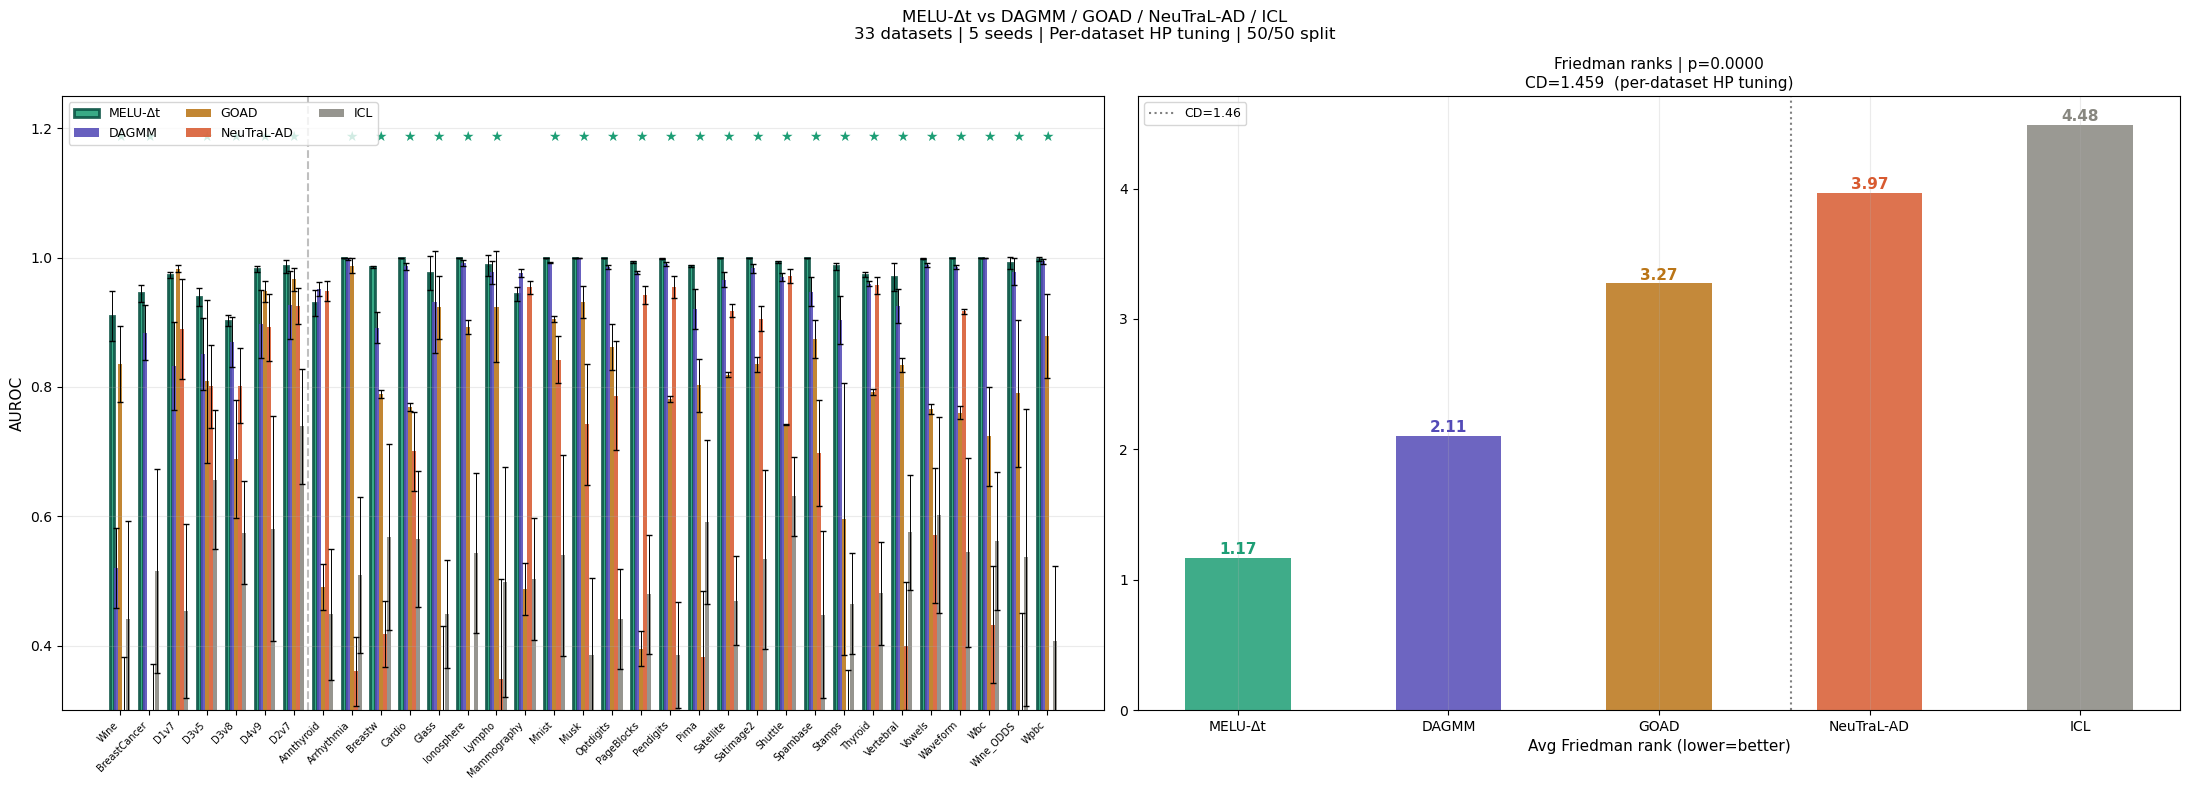

→ outputs/nb16_v2_tuned.png
→ outputs/nb16_v2_results.csv


In [25]:
DS=[d[0] for d in DATASETS]
A={m:np.array([np.mean(results[ds][m]) for ds in DS]) for m in METHODS}
nd=len(DS); n_real=sum(1 for d in DATASETS if d[4]=="sklearn")
sm=np.column_stack([A[m] for m in METHODS])
fs,fp=friedmanchisquare(*sm.T)
rk=np.array([rankdata(-sm[i]) for i in range(nd)]).mean(0)
k=len(METHODS); qt={5:2.728,10:3.164,20:3.578,33:3.748}
q=max(v for kk,v in qt.items() if kk<=nd); CD=q*np.sqrt(k*(k+1)/(6*nd))

fig,axes=plt.subplots(1,2,figsize=(22,8))
fig.suptitle(f"MELU-Δt vs DAGMM / GOAD / NeuTraL-AD / ICL\n"
             f"{nd} datasets | {N_SEEDS_RUN} seeds | Per-dataset HP tuning | 50/50 split",fontsize=12)

ax=axes[0]; x=np.arange(nd); w=0.14; offs=np.linspace(-2,2,k)
for i,m in enumerate(METHODS):
    means=[np.mean(results[ds][m]) for ds in DS]; stds=[np.std(results[ds][m]) for ds in DS]
    ax.bar(x+offs[i]*w,means,width=w,color=COLORS[m],alpha=0.88,label=m,
           linewidth=2.0 if m=="MELU-Δt" else 0.5,
           edgecolor="#085041" if m=="MELU-Δt" else "none")
    ax.errorbar(x+offs[i]*w,means,yerr=stds,fmt="none",ecolor="black",capsize=2,lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(DS,fontsize=7,rotation=45,ha='right')
ax.set_ylabel("AUROC",fontsize=11); ax.set_ylim(0.3,1.25)
ax.legend(fontsize=9,ncol=3); ax.grid(axis="y",alpha=0.25)
if n_real<nd: ax.axvline(n_real-.5,color="gray",lw=1.5,ls="--",alpha=0.5)
for xi,ds in enumerate(DS):
    best=max(np.mean(results[ds][m]) for m in METHODS)
    if np.mean(results[ds]["MELU-Δt"])>=best-0.001:
        ax.text(xi,1.18,"★",ha="center",fontsize=10,color="#1D9E75")

ax=axes[1]
sp=sorted(zip(METHODS,rk),key=lambda x:x[1])
bars=ax.bar([s[0] for s in sp],[s[1] for s in sp],color=[COLORS[s[0]] for s in sp],alpha=0.85,width=0.5)
ax.axvline(min(rk)+CD,color="gray",lw=1.5,ls=":",label=f"CD={CD:.2f}")
ax.set_xlabel("Avg Friedman rank (lower=better)",fontsize=11)
ax.set_title(f"Friedman ranks | p={fp:.4f}\nCD={CD:.3f}  (per-dataset HP tuning)",fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="x",alpha=0.25)
for b,(nm,r) in zip(bars,sp):
    ax.text(b.get_x()+b.get_width()/2,r+0.03,f"{r:.2f}",ha="center",
            fontsize=11,fontweight="bold",color=COLORS[nm])

plt.tight_layout()
plt.savefig("outputs/nb16_v2_tuned.png",dpi=150,bbox_inches="tight")
plt.show(); print("→ outputs/nb16_v2_tuned.png")

pd.DataFrame([{"dataset":ds,"method":m,"source":meta[ds][1],"dim":meta[ds][0],
               "auroc_mean":round(np.mean(results[ds][m]),4),
               "auroc_std":round(np.std(results[ds][m]),4),
               "n_seeds":N_SEEDS_RUN}
              for ds in DS for m in METHODS]
).to_csv("outputs/nb16_v2_results.csv",index=False)
print("→ outputs/nb16_v2_results.csv")
